# CNN/DailyMail — Word-Frequency Extractive Summarizer Demo

This notebook demonstrates a simple **word-frequency based extractive text summarizer** on the CNN/DailyMail 3.0.0 dataset.

**What this artifact does:**
- Loads CNN/DailyMail news articles (test split)
- Scores each sentence by the sum of word frequencies in the article
- Selects the top-k highest-scoring sentences as the extractive summary
- Compares the extractive summary to the reference highlights using ROUGE-style overlap

**Dataset:** 2000 test examples from `abisee/cnn_dailymail` (articles + multi-sentence bullet-point highlights)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed for this demo

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'nltk==3.9.1')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import re
import math
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))
print('Imports OK')

Imports OK


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6a9498-vocabulary-percolation-threshold-for-sel/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data['datasets'][0]['examples']
print(f"Loaded {len(examples)} examples")
print(f"Keys: {list(examples[0].keys())}")

Loaded 3 examples
Keys: ['input', 'output', 'metadata_id', 'metadata_row_index', 'metadata_task_type', 'metadata_source_id']


In [5]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
# Tunable parameters — start at minimum for a fast demo run
N_EXAMPLES = 3          # number of articles to summarize (max: all examples)
N_SUMMARY_SENTENCES = 3 # how many sentences to extract per article
# ────────────────────────────────────────────────────────────────────────────

## Word-Frequency Scoring

The summarizer works in three steps:
1. **Tokenize** the article into sentences (NLTK sent_tokenize)
2. **Count word frequencies** across the whole article (excluding stopwords and punctuation)
3. **Score each sentence** as the sum of its word frequencies, normalized by sentence length

This is a classic baseline for extractive summarization — high-frequency words signal the article's core topics.

In [6]:
def tokenize_words(text):
    """Lowercase, remove punctuation, split into words, filter stopwords."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) > 1]


def word_freq_scores(article_text):
    """Return {word: normalized_frequency} dict for the article."""
    words = tokenize_words(article_text)
    freq = Counter(words)
    max_freq = max(freq.values()) if freq else 1
    return {w: c / max_freq for w, c in freq.items()}


def score_sentences(sentences, freq):
    """Score each sentence by mean word frequency of its content words."""
    scores = []
    for sent in sentences:
        words = tokenize_words(sent)
        if not words:
            scores.append(0.0)
            continue
        score = sum(freq.get(w, 0) for w in words) / len(words)
        scores.append(score)
    return scores


def extractive_summarize(article_text, n_sentences=3):
    """Return top-n sentences from article ranked by word frequency score."""
    sentences = sent_tokenize(article_text)
    if len(sentences) <= n_sentences:
        return sentences, list(range(len(sentences))), [1.0] * len(sentences)
    freq = word_freq_scores(article_text)
    scores = score_sentences(sentences, freq)
    # Rank sentences by score, keep original order in output
    ranked_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    top_idx = sorted(ranked_idx[:n_sentences])
    return [sentences[i] for i in top_idx], top_idx, [scores[i] for i in top_idx]


print('Summarizer functions defined')

Summarizer functions defined


## ROUGE-1 Overlap

To evaluate the extractive summary quality, we compute **ROUGE-1 F1**: the unigram overlap between the generated summary and the reference highlights.

ROUGE-1 F1 = harmonic mean of precision (what fraction of summary words appear in reference) and recall (what fraction of reference words appear in summary).

In [7]:
def rouge1_f1(hypothesis, reference):
    """Compute ROUGE-1 F1 between hypothesis and reference strings."""
    hyp_words = set(tokenize_words(hypothesis))
    ref_words = set(tokenize_words(reference))
    if not hyp_words or not ref_words:
        return 0.0
    overlap = hyp_words & ref_words
    precision = len(overlap) / len(hyp_words)
    recall = len(overlap) / len(ref_words)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


print('ROUGE-1 function defined')

ROUGE-1 function defined


## Run Summarizer on Examples

For each article, we extract the top sentences and compare to the reference highlights.

In [8]:
results = []

for ex in examples[:N_EXAMPLES]:
    article = ex['input']
    reference = ex['output']
    doc_id = ex['metadata_id']

    summary_sents, top_idx, sent_scores = extractive_summarize(article, n_sentences=N_SUMMARY_SENTENCES)
    summary_text = ' '.join(summary_sents)

    r1 = rouge1_f1(summary_text, reference)
    n_article_sents = len(sent_tokenize(article))
    n_article_words = len(article.split())
    n_ref_words = len(reference.split())

    results.append({
        'id': doc_id,
        'n_article_sentences': n_article_sents,
        'n_article_words': n_article_words,
        'n_ref_words': n_ref_words,
        'selected_sentence_indices': top_idx,
        'selected_scores': sent_scores,
        'summary': summary_text,
        'reference': reference,
        'rouge1_f1': r1,
    })
    print(f"{doc_id}: {n_article_sents} sents → selected {top_idx}, ROUGE-1={r1:.3f}")

print(f"\nDone. {len(results)} articles processed.")

cnndm_test_0000: 27 sents → selected [17, 19, 20], ROUGE-1=0.128
cnndm_test_0001: 19 sents → selected [4, 5, 9], ROUGE-1=0.136
cnndm_test_0002: 39 sents → selected [1, 23, 26], ROUGE-1=0.250

Done. 3 articles processed.


## Results: Summary vs. Reference

Let's inspect the extracted summaries and their reference highlights side by side.

In [9]:
for r in results:
    print(f"{'='*70}")
    print(f"ID: {r['id']}  |  Article: {r['n_article_words']} words, {r['n_article_sentences']} sentences")
    print(f"ROUGE-1 F1: {r['rouge1_f1']:.3f}")
    print(f"\n[EXTRACTED SUMMARY]")
    print(r['summary'][:600])
    print(f"\n[REFERENCE HIGHLIGHTS]")
    print(r['reference'][:400])
    print()

ID: cnndm_test_0000  |  Article: 567 words, 27 sentences
ROUGE-1 F1: 0.128

[EXTRACTED SUMMARY]
"As we have said repeatedly, we do not believe that Palestine is a state and therefore we do not believe that it is eligible to join the ICC," the State Department said in a statement. "We will continue to oppose actions against Israel at the ICC as counterproductive to the cause of peace," it said. But the ICC begs to differ with the definition of a state for its purposes and refers to the territories as "Palestine."

[REFERENCE HIGHLIGHTS]
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

ID: cnndm_test_0001  |  Article: 411 words, 19 sentences
ROUGE-1 F1: 0.136

[EXTRACTED SUMMARY]
She was taken in by Moses Lake, Washington, resident Sara Mellado. "Considering everything that she's been through, she's incre

## Visualization

Sentence scores across each article — which sentences scored highest and were selected for the summary.

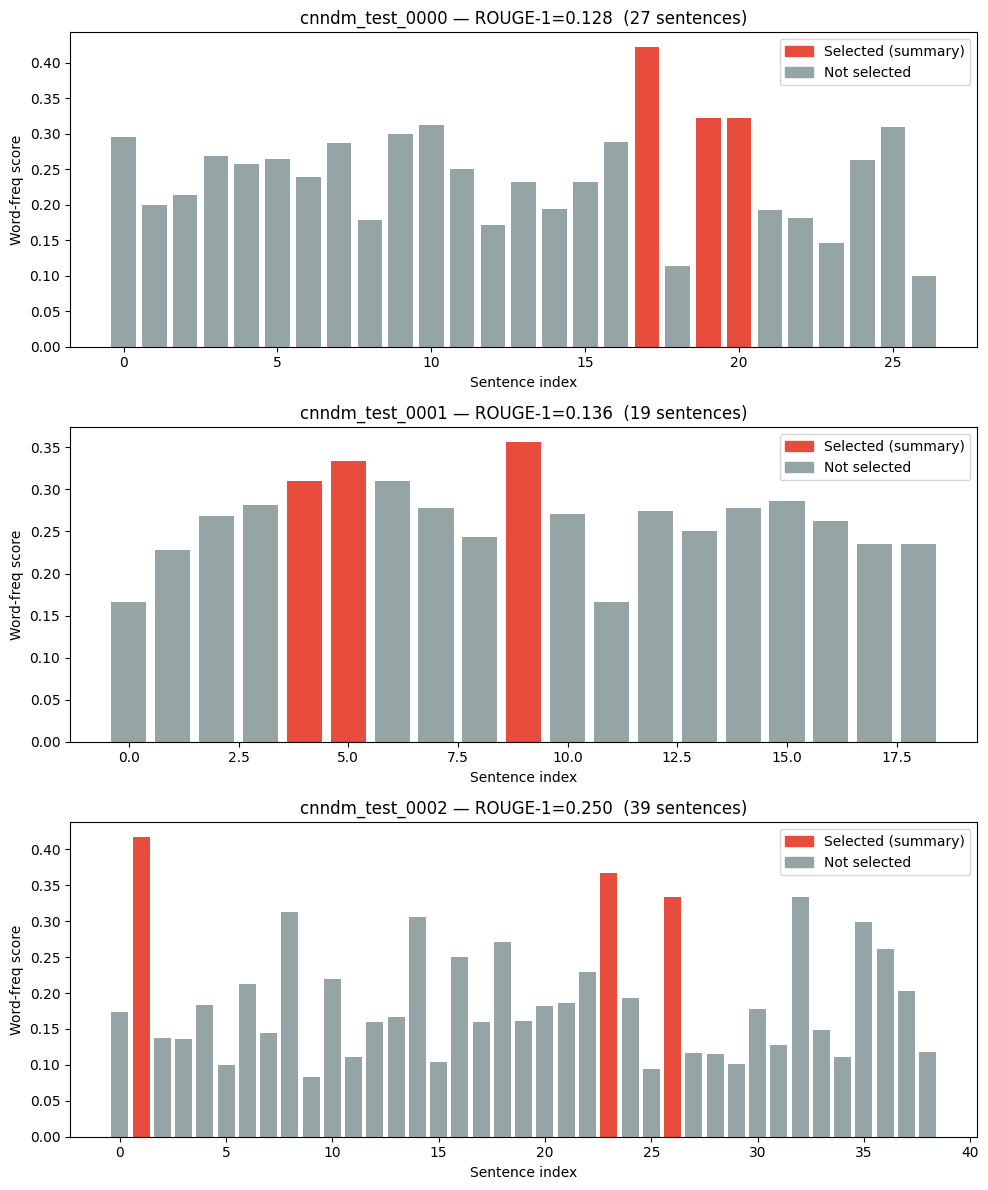


Summary metrics:
             id  article_words  article_sents  ref_words  rouge1_f1
cnndm_test_0000            567             27         36      0.128
cnndm_test_0001            411             19         44      0.136
cnndm_test_0002            704             39         38      0.250

Mean ROUGE-1 F1: 0.171


In [10]:
fig, axes = plt.subplots(len(results), 1, figsize=(10, 4 * len(results)))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    article = next(e['input'] for e in examples if e['metadata_id'] == r['id'])
    sents = sent_tokenize(article)
    freq = word_freq_scores(article)
    all_scores = score_sentences(sents, freq)

    colors = ['#e74c3c' if i in r['selected_sentence_indices'] else '#95a5a6'
              for i in range(len(all_scores))]
    ax.bar(range(len(all_scores)), all_scores, color=colors, width=0.8)
    ax.set_title(f"{r['id']} — ROUGE-1={r['rouge1_f1']:.3f}  ({len(sents)} sentences)")
    ax.set_xlabel('Sentence index')
    ax.set_ylabel('Word-freq score')
    ax.legend(
        handles=[
            matplotlib.patches.Patch(color='#e74c3c', label='Selected (summary)'),
            matplotlib.patches.Patch(color='#95a5a6', label='Not selected'),
        ],
        loc='upper right',
    )

plt.tight_layout()
plt.show()

# Summary table
df = pd.DataFrame([{
    'id': r['id'],
    'article_words': r['n_article_words'],
    'article_sents': r['n_article_sentences'],
    'ref_words': r['n_ref_words'],
    'rouge1_f1': round(r['rouge1_f1'], 3),
} for r in results])
print("\nSummary metrics:")
print(df.to_string(index=False))
print(f"\nMean ROUGE-1 F1: {df['rouge1_f1'].mean():.3f}")